### TES DATA

In [5]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import point

desa = gpd.read_file(
    r"../data/batas_wilayah/Batas_Wilayah_KelurahanDesa_10K_AR.shp", 
    where="WADMKK = 'Bandung'" 
)

print(f"Berhasil.....\nDitemukan {len(desa)} desa/kelurahan di Kabupaten Bandung.\nCRS Polygon:{desa.crs}")

Berhasil.....
Ditemukan 280 desa/kelurahan di Kabupaten Bandung.
CRS Polygon:EPSG:4326


In [6]:
# catatan. titik desa ada 280 titik desa di kab bandung CRS POLYGON adalah EPSD:4326 #

In [7]:
status = {"jumlah desa": f"{len(desa)}",
          "CRS Polygon": f"{desa.crs}"}

df = pd.DataFrame([status])
df

,jumlah desa,CRS Polygon
0,280,EPSG:4326


### Berikut adalah versi pipeline

In [9]:
from src.pip_core import pip_pipeline

# statement kan dulu keperluan
shp_path = "../data/batas_wilayah/Batas_Wilayah_KelurahanDesa_10K_AR.shp" # ini database polygon dalam bentuk .shp
csv_path = "../data/data_existing/DATA_BERSIH_RADIUS.csv"                 # ini datasets titik koordinat gps
polygon_kabupaten = "Bandung"                                             # polygon kabupaten yang ingin digunakan, e.g ("bandung") harus sesuai dengan data, bisa dicek dulu
sep = ";"                                                                 # cek delimeter data .csv kamu
lon = "longitude"                                                         # cek di data kamu kolom lon namanya apa
lat = "latitude"                                                          # cek di data kamu kolom lat namanya apa
output_dir = "../data/output/kecamatan"                                                             # direktori output

pip_result = pip_pipeline(
    shp_path=shp_path,
    csv_path=csv_path,
    polygon=polygon_kabupaten,
    sep=sep,
    lon_col=lon,
    lat_col=lat,
    output_dir=output_dir

)

Sedang memuat data polygon dari ../data/batas_wilayah/Batas_Wilayah_KelurahanDesa_10K_AR.shp
Sedang memuat dataset dari ../data/data_existing/DATA_BERSIH_RADIUS.csv
Mohon tunggu......
Proses selesai


In [ ]:
pip_result.columns

Index(['latitude', 'longitude', 'name', 'geometry', 'index_right', 'WADMKC',
       'WADMKD'],
      dtype='object')

<Axes: >

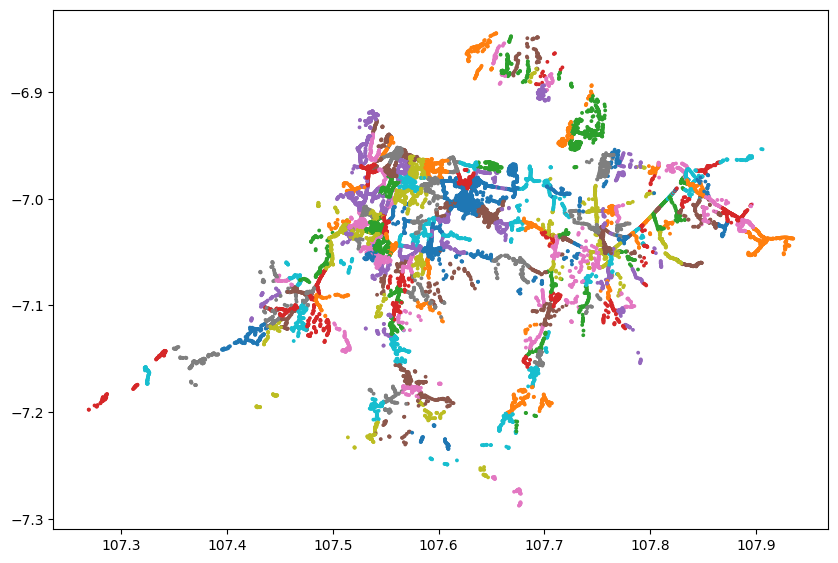

In [10]:
import matplotlib.pyplot as plt

pip_result.plot(
    column="WADMKD",
    figsize=(10, 8),
    markersize=3,
    legend=False
)

latitude       694
longitude      694
name           694
geometry       694
index_right    694
WADMKC         694
WADMKD         694
dtype: int64


<Axes: >

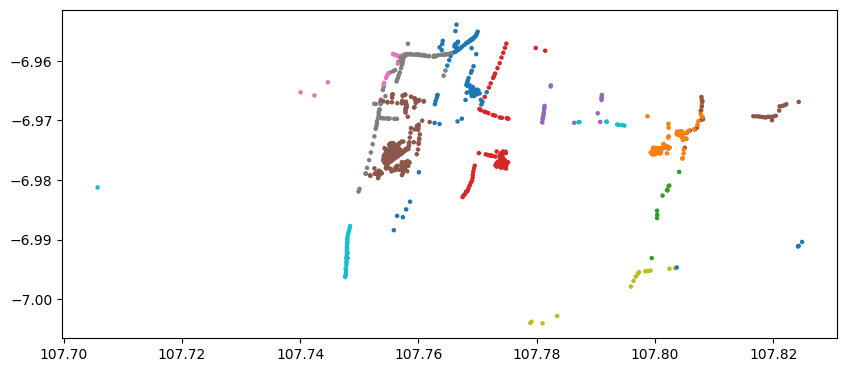

In [12]:
kec = 'Rancaekek'
subset = pip_result[pip_result['WADMKC'] == kec]
print(f"{subset.count()}")
subset.plot(
    column='WADMKD',
    figsize=(10,10),
    markersize=5,
    legend=False
)

In [1]:
from src.visualize_satellite import satVis

file_path = "../data/data_existing/DATA_BERSIH_RADIUS.csv"

result = satVis(file_path,
                sep=";")


Folder ../data/output/map/ berhasil dibuat.
Map saved as 'satellite_visualization.html'. Open it in a web browser to view.


#### Berikut adalah versi terdahulu, step by step

## PEMBUATAN FUNCTION MULAI DARI BAWAH SINI
### FUNCTION PIP_EXPERIMENT():

#### 1. Load polygon dataset (desa/kelurahan)
#### 2. Ensure CRS consistency
#### 3. Load point dataset
#### 4. Perform point-in-polygon (point → desa)
#### 5. Attach administrative attributes (kecamatan)
#### 6. Export results (per kecamatan / per desa)


In [1]:
from src.pip_core import (
    load_polygon_admin,
    load_points_datasets,
    run_pip,
    export_by_kecamatan)

# load batas wilayah sebagai polygon

desa = load_polygon_admin(
    "../data/batas_wilayah/Batas_Wilayah_KelurahanDesa_10K_AR.shp",
    kabupaten='Bandung'
    )


In [2]:
help(load_points_datasets)

Help on function load_points_datasets in module src.pip_core:

load_points_datasets(
    csv_path: str,
    sep: str = ';',
    lon_col: str = 'longitude',
    lat_col: str = 'latitude',
    crs=None
) -> geopandas.geodataframe.GeoDataFrame



In [2]:
csv_path="../data/data_existing/DATA_BERSIH_RADIUS.csv"

points = load_points_datasets(
    csv_path=csv_path,
    sep=';',
    lon_col="longitude", 
    lat_col="latitude",
    crs=desa.crs)



In [4]:
pip_results = run_pip(
    points_gdf=points,
    polygon_gdf=desa)

pip_results.head()

,latitude,longitude,name,geometry,index_right,WADMKC,WADMKD
0,-7.03350,107.70821,(1300 VA),POINT (107.70821 -7.0335),158,Ciparay,Sarimahi
1,-7.02030,107.52908,0011,POINT (107.52908 -7.0203),249,Soreang,Pamekaran
2,-6.99598,107.74772,24-JUL-17 13:06:06,POINT (107.74772 -6.99598),200,Rancaekek,Sukamanah
3,-7.00942,107.61916,00111,POINT (107.61916 -7.00942),182,Baleendah,Baleendah
4,-6.99180,107.53228,2017-07-22 9:17:17AM,POINT (107.53228 -6.9918),205,Kutawaringin,Cibodas


In [5]:
pip_results.value_counts()

latitude  longitude  name                   geometry                    index_right  WADMKC     WADMKD    
-7.28772  107.67594  2018-06-26 12:23:31PM  POINT (107.67594 -7.28772)  0            Kertasari  Neglawangi    1
-7.28739  107.67631  2018-06-26 12:22:51PM  POINT (107.67631 -7.28739)  0            Kertasari  Neglawangi    1
-7.28709  107.67662  5514                   POINT (107.67662 -7.28709)  0            Kertasari  Neglawangi    1
-7.28655  107.67709  5505                   POINT (107.67709 -7.28655)  0            Kertasari  Neglawangi    1
-7.28623  107.67724  5495                   POINT (107.67724 -7.28623)  0            Kertasari  Neglawangi    1
                                                                                                             ..
-6.84549  107.65261  11-JUL-17 16:50:49     POINT (107.65261 -6.84549)  265          Cimenyan   Ciburial      1
-6.84513  107.65338  11-JUL-17 16:51:12     POINT (107.65338 -6.84513)  265          Cimenyan   Ciburial     

In [6]:
export_by_kecamatan(
    pip_results,
    "../data/output/kecamatan"
)